In [2]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt
import seaborn as sns
print("libraries imported successfully")

libraries imported successfully


In [3]:
data = pd.read_csv('diabetes_dataset.csv')
print("data loaded successfully")


data loaded successfully


In [4]:
print("Number of rows:", data.shape[0])
print("Number of columns:", data.shape[1])


Number of rows: 768
Number of columns: 9


In [5]:
print(data.describe())

       Pregnancies     Glucose  BloodPressure  SkinThickness     Insulin  \
count   768.000000  768.000000     768.000000     768.000000  768.000000   
mean      3.845052  120.894531      69.105469      20.536458   79.799479   
std       3.369578   31.972618      19.355807      15.952218  115.244002   
min       0.000000    0.000000       0.000000       0.000000    0.000000   
25%       1.000000   99.000000      62.000000       0.000000    0.000000   
50%       3.000000  117.000000      72.000000      23.000000   30.500000   
75%       6.000000  140.250000      80.000000      32.000000  127.250000   
max      17.000000  199.000000     122.000000      99.000000  846.000000   

              BMI  DiabetesPedigreeFunction         Age     Outcome  
count  768.000000                768.000000  768.000000  768.000000  
mean    31.992578                  0.471876   33.240885    0.348958  
std      7.884160                  0.331329   11.760232    0.476951  
min      0.000000                  

In [6]:
missing_values = data.isnull().sum()
print("Missing values in each column:\n", missing_values)
duplicate_rows = data.duplicated().sum()
for col in data.columns:
    if data[col].duplicated().any():
        duplicate_colums = col

Missing values in each column:
 Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [7]:
median_valuesBP = data['BloodPressure'].median()
print("\n Median values of each column:", median_valuesBP)
data['BloodPressure']=data['BloodPressure'].replace(0, median_valuesBP)




 Median values of each column: 72.0


In [8]:
median_valuesSK = data['SkinThickness'].median()
print("\n Median values of each column:", median_valuesSK)
data['SkinThickness']=data['SkinThickness'].replace(0, median_valuesSK)


 Median values of each column: 23.0


In [9]:
median_valuesIN = data['Insulin'].median()
print("\n Median values of each column:", median_valuesIN)
data['Insulin']=data['Insulin'].replace(0, median_valuesIN)


 Median values of each column: 30.5


In [10]:
median_valuesBMI = data['BMI'].median()
print("\n Median values of each column:", median_valuesBMI)
data['BMI']=data['BMI'].replace(0, median_valuesBMI)


 Median values of each column: 32.0


In [11]:
print(data.head(20))

    Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0             6      148             72             35     30.5  33.6   
1             1       85             66             29     30.5  26.6   
2             8      183             64             23     30.5  23.3   
3             1       89             66             23     94.0  28.1   
4             0      137             40             35    168.0  43.1   
5             5      116             74             23     30.5  25.6   
6             3       78             50             32     88.0  31.0   
7            10      115             72             23     30.5  35.3   
8             2      197             70             45    543.0  30.5   
9             8      125             96             23     30.5  32.0   
10            4      110             92             23     30.5  37.6   
11           10      168             74             23     30.5  38.0   
12           10      139             80            

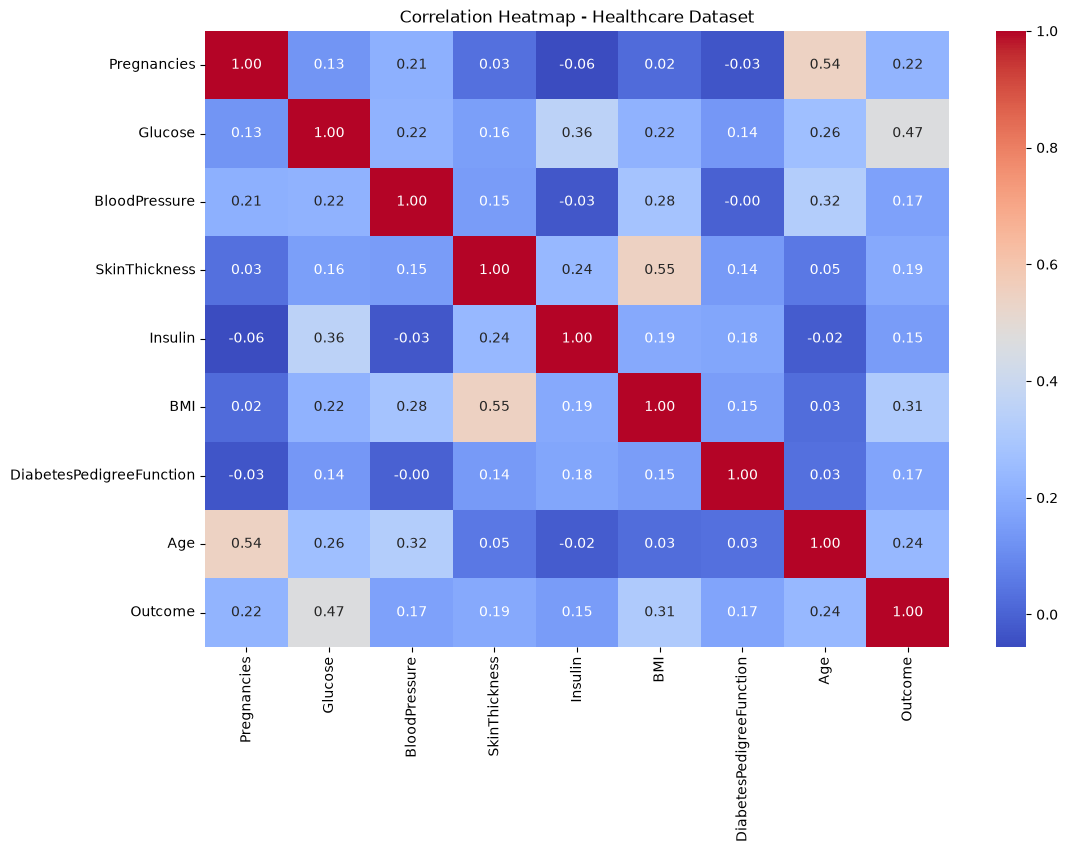

In [12]:
correlation = data.corr(numeric_only=True)
plt.figure(figsize=(12, 8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap - Healthcare Dataset")
plt.show()

MODEL 1 :LINEAR REGREESSION

In [13]:
X = data[[ 'Glucose', 'SkinThickness', 'BMI', 'Age']]
y = data['Outcome']



X_train, X_test, y_train, y_test = train_test_split(
    X,y,test_size=0.2,random_state=42
)

model1 = LinearRegression()
model1.fit(X_train, y_train)
y_pred1 = model1.predict(X_test)
score1 = r2_score(y_test, y_pred1)
print("R² Score:", round(score1, 4))



R² Score: 0.2238


MODEL 2 (ALL ELEMENTS)IN LINEAR REGRESSION

In [14]:
X2= data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y2 = data['Outcome']
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,y2,test_size=0.2,random_state=42)
model2 = LinearRegression()
model2.fit(X2_train, y2_train)
y2_pred = model2.predict(X2_test)
score2 = r2_score(y2_test, y2_pred)
print("R² Score for model 2:", round(score2, 4))



R² Score for model 2: 0.2692


LOGISTIC REGRESSION


In [15]:
X3= data[['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']]
y3 = data['Outcome']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,y3,test_size=0.2,random_state=42)
model3 = LogisticRegression()
model3.fit(X3_train, y3_train)
y3_pred = model3.predict(X3_test)
accuracy3 = accuracy_score(y3_test, y3_pred)
print("Accuracy for model 3:", round(accuracy3, 4))



Accuracy for model 3: 0.7727


C:\Users\sidhu\AppData\Roaming\Python\Python314\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


TAKING THE SAME ELEMENTS(GLUCOSE,SKIN THICKNESS,BMI,AGE VS OUTCOME )  FROM HEATMAP FOR DECISION TREE 80:20

In [16]:
X4= data[[ 'Glucose', 'SkinThickness', 'BMI', 'Age']]
y4= data['Outcome']



X4_train, X4_test, y4_train, y4_test = train_test_split(
    X4,y4,test_size=0.2,random_state=42
)


model4 = DecisionTreeClassifier(random_state=42)
model4.fit(X4_train, y4_train)
y4_pred = model4.predict(X4_test)
score4 = accuracy_score(y4_test, y4_pred)
print("Accuracy Score:", round(score4, 4))


Accuracy Score: 0.6688


In [17]:
X5 = data[[ 'Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'DiabetesPedigreeFunction', 'SkinThickness', 'BMI', 'Age']]
y5 = data['Outcome']



X5_train, X5_test, y5_train, y5_test = train_test_split(
    X5,y5,test_size=0.2,random_state=42
)
model5 = DecisionTreeClassifier(random_state=42)
model5.fit(X5_train, y5_train)
y_pred5 = model5.predict(X5_test)
score5 = accuracy_score(y5_test, y_pred5)
print("Accuracy Score:", round(score5, 4))






Accuracy Score: 0.7143


90:10 SPLIT FOR ALL ELEMENTS IN DECISION TREE [GIVING MORE ACCURACY THAN 80:20]

In [18]:
X6 = data[[ 'Pregnancies', 'Glucose', 'BloodPressure', 'Insulin', 'DiabetesPedigreeFunction', 'SkinThickness', 'BMI', 'Age']]
y6 = data['Outcome']



X6_train, X6_test, y6_train, y6_test = train_test_split(
    X6,y6,test_size=0.1,random_state=42
)
model6 = DecisionTreeClassifier(random_state=42)
model6.fit(X6_train, y6_train)
y_pred6 = model6.predict(X6_test)
score6 = accuracy_score(y6_test, y_pred6)
print("Accuracy Score:", round(score6, 4))
error6 = 1 - score6
print("Error Rate:", round(error6, 4))

Accuracy Score: 0.7532
Error Rate: 0.2468


COMPARISION BETWEEN ALL THE MODELS

In [19]:
compare = pd.DataFrame({
    'MODEL TYPE': ['LINEAR REGRESSION','LINEAR REGRESSION', 'LOGISTIC REGRESSION', 'DECISION TREE', 'DECISION TREE', 'DECISION TREE'],
    'ELEMENTS CONSIDERED': ['GLUCOSE,SKIN THICKNESS,BMI,AGE','ALL ELEMENTS', 'ALL ELEMENTS', 'GLUCOSE,SKIN THICKNESS,BMI,AGE', 'ALL ELEMENTS', 'ALL ELEMENTS'],
    'SPLIT RATIO': ['80:20','80:20', '80:20', '80:20', '80:20', '90:10'],
    'Accuracy': [score1,score2, accuracy3, score4, score5, score6],
    

    

})
compare

,MODEL TYPE,ELEMENTS CONSIDERED,SPLIT RATIO,Accuracy
0,LINEAR REGRESSION,"GLUCOSE,SKIN THICKNESS,BMI,AGE",80:20,0.223782
1,LINEAR REGRESSION,ALL ELEMENTS,80:20,0.269210
2,LOGISTIC REGRESSION,ALL ELEMENTS,80:20,0.772727
3,DECISION TREE,"GLUCOSE,SKIN THICKNESS,BMI,AGE",80:20,0.668831
4,DECISION TREE,ALL ELEMENTS,80:20,0.714286
5,DECISION TREE,ALL ELEMENTS,90:10,0.753247


In [20]:
patient={
    'Pregnancies': 2,
    'Glucose': 120,
    'BloodPressure': 70,
    'SkinThickness': 20,
    'Insulin': 79,
    'BMI': 25.6,
    'DiabetesPedigreeFunction': 0.5,
    'Age': 33
}
ypred7=model6.predict([list(patient.values())])
print("PATIENT DATA: \n", patient)
print("\n PREDICTED OUTCOME FOR THE PATIENT:", ypred7)
if ypred7==1:
    print("\n THE PATIENT IS LIKELY TO HAVE DIABETES.")
else:
    print("\n THE PATIENT IS UNLIKELY TO HAVE DIABETES.")

pateint2={
    'Pregnancies': 5,
    'Glucose': 189,
    'BloodPressure': 80,
    'SkinThickness': 50,
    'Insulin': 846,
    'BMI': 60.0,
    'DiabetesPedigreeFunction': 0.69,
    'Age': 76
}
ypred8=model6.predict([list(pateint2.values())])
print("PATIENT DATA: \n", pateint2)
print("\n PREDICTED OUTCOME FOR THE PATIENT:", ypred8)
if ypred8==1:
    print("\n THE PATIENT IS LIKELY TO HAVE DIABETES.")
else:
    print("\n THE PATIENT IS UNLIKELY TO HAVE DIABETES.")





PATIENT DATA: 
 {'Pregnancies': 2, 'Glucose': 120, 'BloodPressure': 70, 'SkinThickness': 20, 'Insulin': 79, 'BMI': 25.6, 'DiabetesPedigreeFunction': 0.5, 'Age': 33}

 PREDICTED OUTCOME FOR THE PATIENT: [0]

 THE PATIENT IS UNLIKELY TO HAVE DIABETES.
PATIENT DATA: 
 {'Pregnancies': 5, 'Glucose': 189, 'BloodPressure': 80, 'SkinThickness': 50, 'Insulin': 846, 'BMI': 60.0, 'DiabetesPedigreeFunction': 0.69, 'Age': 76}

 PREDICTED OUTCOME FOR THE PATIENT: [0]

 THE PATIENT IS UNLIKELY TO HAVE DIABETES.


C:\Users\sidhu\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\sidhu\AppData\Roaming\Python\Python314\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
